In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from module import make_ff_factors, performance_metrics

plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

In [4]:
mkt_cap             = pd.read_csv('../../00_input/KOSPI_KOSDAQ_mkt_cap.csv', index_col='Date', parse_dates=True)
KOSPI               = pd.read_csv('../../00_input/KOSPI_index.csv', index_col='Date', parse_dates=True)
adj_close_df        = pd.read_csv('../../00_input/KOSPI_KOSDAQ_adj_close.csv', index_col='Date', parse_dates=True)
factors             = pd.read_csv('../../00_input/Factors.csv', index_col='Date', parse_dates=True)
total_adj_close     = pd.read_csv('../../00_input/KOSPI_KOSDAQ_total_adj_close.csv', index_col='Date', parse_dates=True)
trading_value_60    = pd.read_csv('../../00_input/KOSPI_KOSDAQ_trading_value_60.csv', index_col='Date', parse_dates=True)
trading_value       = pd.read_csv('../../00_input/KOSPI_KOSDAQ_trading_value.csv', index_col='Date', parse_dates=True)

---
##### **데이터 전처리**

주식, 시장 초과수익률 계산

In [7]:
# 일별 단순 수익률
daily_ret = adj_close_df.pct_change(fill_method=None)

# KOSPI 일별 단순 수익률
KOSPI_ret = KOSPI.pct_change(fill_method=None)

In [17]:
# 1) RF(=CD 연율 %)을 일별 무위험수익률로 변환
rf_annual_pct = pd.to_numeric(factors["RF"], errors="coerce")  # 예: 1.53 = 1.53%
rf_daily = (1 + rf_annual_pct / 100.0) ** (1/252) - 1         # 일별 단순 수익률

In [18]:
start_date = pd.Timestamp('1994-06-29')

# (1) 공통 인덱스: 세 객체의 날짜(인덱스) 교집합
common_index = daily_ret.index
common_index = common_index.intersection(
    getattr(KOSPI_ret, 'index', common_index)
)
common_index = common_index.intersection(
    getattr(rf_daily, 'index', common_index)
)

# (2) 원하는 시작일 이후로 제한
common_index = common_index[common_index >= start_date]

# (3) 각각 공통 인덱스로 슬라이싱/재정렬
daily_ret = daily_ret.loc[common_index]
KOSPI_ret    = KOSPI_ret.loc[common_index]
rf_daily       = rf_daily.loc[common_index]

In [26]:
# 2) excess return 계산
stock_excess = daily_ret.sub(rf_daily, axis=0)
market_excess = KOSPI_ret.squeeze() - rf_daily

downside beta 계산

In [72]:
def compute_downside_beta(
    stock_excess: pd.DataFrame,
    market_excess: pd.Series,
    window: int = 252,
    min_obs: int = 120,
    min_downside_obs: int = 40,
) -> pd.DataFrame:
    stock_excess = stock_excess.sort_index()
    market_excess = market_excess.sort_index()

    common_index = stock_excess.index.intersection(market_excess.index)
    stock_excess = stock_excess.loc[common_index]
    market_excess = market_excess.loc[common_index]

    month_ends = stock_excess.groupby(stock_excess.index.to_period("M")).apply(lambda x: x.index[-1])
    month_ends = pd.DatetimeIndex(month_ends.values)

    factor_df = pd.DataFrame(index=month_ends, columns=stock_excess.columns, dtype=float)

    for end_date in month_ends:
        end_loc = common_index.get_loc(end_date)
        if end_loc < window - 1:
            continue

        window_index = common_index[end_loc - window + 1 : end_loc + 1]

        stock_win = stock_excess.loc[window_index]
        market_win = market_excess.loc[window_index]

        mu_m = market_win.mean()
        downside_mask = market_win < mu_m

        X = stock_win.loc[downside_mask].to_numpy(dtype=float)   # (T_down, N)
        m = market_win.loc[downside_mask].to_numpy(dtype=float)  # (T_down,)

        valid_mask = ~np.isnan(X)
        downside_counts = valid_mask.sum(axis=0)
        full_counts = stock_win.notna().sum(axis=0).to_numpy()

        # 시장 하방 구간 분산
        var_m_down = np.var(m, ddof=1)
        if not np.isfinite(var_m_down) or var_m_down == 0:
            continue

        # 열별 평균
        x_mean = np.divide(
            np.nansum(X, axis=0),
            downside_counts,
            out=np.full(X.shape[1], np.nan),
            where=downside_counts > 0,
        )
        m_mean = m.mean()

        # 공분산 계산
        X_centered = X - x_mean
        m_centered = m[:, None] - m_mean

        cov_num = np.nansum(X_centered * m_centered, axis=0)
        cov_den = downside_counts - 1

        cov = np.divide(
            cov_num,
            cov_den,
            out=np.full(X.shape[1], np.nan),
            where=cov_den > 0,
        )

        beta = cov / var_m_down

        factor_df.loc[end_date] = beta

    return factor_df


In [81]:
factor_df = compute_downside_beta(
    stock_excess=stock_excess,
    market_excess=market_excess,
    window=252,
    min_obs=252,
    min_downside_obs=40,
)
factor_df = factor_df.resample("ME").last()

In [82]:
# 월간 데이터 계산
monthly_rets      = total_adj_close.resample('ME').last().pct_change(fill_method=None)

# 수익률 윈저라이징
monthly_rets_wins = monthly_rets.clip(
    lower=monthly_rets.quantile(0.01),
    upper=monthly_rets.quantile(0.99),
    axis=1
)

In [83]:
# 일별 수익률과 거래대금을 이용해 Amihud illiquidity 계산
daily_ret        = adj_close_df.pct_change(fill_method=None)
daily_illiq      = (daily_ret.abs()/trading_value)
illiq            = daily_illiq.resample('ME').mean()

---
##### **리밸런싱 날짜 설정**

In [ ]:
# 백테스트 기간을 설정하여 월말 날짜 리스트 생성
start_point = '1999-12-31'
end_point   = '2026-02-28'

month_ends  = pd.date_range(start=start_point, end=end_point, freq='ME')

In [185]:
# 종목 수 선정
n                      = 20  

# 가중방식 선택
weight_method_temp     = "Cap"  # ['Equal'(동일가중), Cap'(시가총액가중)]

# 유동성 하위 종목 제외
trading_threshold      = 0.10     # 유동성 하위 종목 제외

# 거래대금 설정
high_cost              = 0.008    # 80bp
low_cost               = 0.003    # 30bp
illiq_threshold        = 0.80     # Amihud 유동성 기준 상위 20%

portfolio_return       = pd.Series(dtype=float)
total_trade            = pd.Series(dtype=float)

initial_NAV            = 1        # 초기값
NAV                    = initial_NAV

---
##### **전체 기간 포트폴리오 수익률 계산**

In [186]:
portfolio_return = pd.Series(index=month_ends, dtype=float)
total_trade      = pd.Series(index=month_ends, dtype=float)
prev_portfolio   = pd.Series(dtype=float)

portfolio_return[month_ends[0]] = 0.0
NAV = initial_NAV

In [187]:
# for i in range(len(month_ends) - 1):

#     # 매기간 날짜 업데이트
#     start_date  = month_ends[i]
#     end_date    = month_ends[i + 1]

#     # 거래대금 하위 종목 제외
#     trading_today      = trading_value_60.loc[start_date].dropna()
#     filtered           = trading_today[trading_today > trading_today.quantile(trading_threshold)].index

#     factor_filtered    = factor_df.loc[start_date, filtered].dropna()

#     # 종목 선정
#     basket = factor_filtered.nlargest(n).index

#     # 유동성 반영
#     illiq_startdate = illiq.loc[start_date].dropna()
#     threshold       = illiq_startdate.quantile(illiq_threshold)
#     illiquid_top20  = illiq_startdate[illiq_startdate >= threshold].index

#     # 가중방식 선택
#     prev_weights   = prev_portfolio / prev_portfolio.sum()
    
#     # 동일가중
#     if weight_method_temp == 'Equal':
#         target_weights = pd.Series(1.0/len(basket), index=basket)

#     # 시가총액가중
#     else:
#         cap = mkt_cap.loc[start_date, basket]
#         target_weights = cap/cap.sum()

#     # 거래비용 반영
#     all_index = target_weights.index.union(prev_weights.index)
#     target_w = target_weights.reindex(all_index, fill_value=0)
#     prev_w   = prev_weights.reindex(all_index, fill_value=0)

#     delta_w   = target_w - prev_w
#     trade_amounts = abs(delta_w) * NAV
#     cost_rate = np.where(delta_w.index.isin(illiquid_top20), high_cost, low_cost)

#     trade_cost = (trade_amounts * cost_rate).sum()

#     NAV_new = NAV - trade_cost
    
#     current_portfolio_value = target_weights * NAV_new

#     # 당기 포트폴리오 최종 가치 계산
#     ret_seg              = monthly_rets_wins.loc[end_date, basket]
#     next_portfolio_value = current_portfolio_value * (ret_seg + 1)

#     # 당기 포트폴리오 수익률 계산
#     NAV_new       = next_portfolio_value.sum()
#     portfolio_ret = NAV_new / NAV - 1

#     # prev_portfolio 업데이트
#     prev_portfolio = next_portfolio_value

#     # NAV 업데이트
#     NAV = NAV_new

#     # 총 거래금액 저장
#     total_trade.loc[start_date] = trade_amounts.sum()
    
#     # 포트폴리오 수익률 저장
#     portfolio_return.loc[end_date] = portfolio_ret

In [188]:
bottom_pct = 0.20  # 하위 20%

for i in range(len(month_ends) - 1):

    # 매기간 날짜 업데이트
    start_date = month_ends[i]
    end_date   = month_ends[i + 1]

    # 거래대금 하위 종목 제외
    trading_today = trading_value_60.loc[start_date].dropna()
    filtered = trading_today[trading_today > trading_today.quantile(trading_threshold)].index

    factor_filtered = factor_df.loc[start_date, filtered].dropna()

    # 종목 선정: factor 하위 20%
    if factor_filtered.empty:
        portfolio_return.loc[end_date] = np.nan
        total_trade.loc[start_date] = 0.0
        continue

    n_select = max(1, int(np.ceil(len(factor_filtered) * bottom_pct)))
    basket = factor_filtered.nlargest(n_select).index

    # 유동성 반영
    illiq_startdate = illiq.loc[start_date].dropna()
    threshold = illiq_startdate.quantile(illiq_threshold)
    illiquid_top20 = illiq_startdate[illiq_startdate >= threshold].index

    # 가중방식 선택
    prev_weights = prev_portfolio / prev_portfolio.sum() if prev_portfolio.sum() != 0 else pd.Series(dtype=float)

    # 동일 가중
    if weight_method_temp == 'Equal':
        target_weights = pd.Series(1.0 / len(basket), index=basket)

    # 시가 총액 가중
    else:
        cap = mkt_cap.loc[start_date, basket].dropna()
        target_weights = cap / cap.sum()
        basket = target_weights.index  # 결측 cap 제거 반영

    # 거래비용 반영
    all_index = target_weights.index.union(prev_weights.index)
    target_w = target_weights.reindex(all_index, fill_value=0)
    prev_w = prev_weights.reindex(all_index, fill_value=0)

    delta_w = target_w - prev_w
    trade_amounts = abs(delta_w) * NAV
    cost_rate = np.where(delta_w.index.isin(illiquid_top20), high_cost, low_cost)

    trade_cost = (trade_amounts * cost_rate).sum()

    NAV_new = NAV - trade_cost
    current_portfolio_value = target_weights * NAV_new

    # 당기 포트폴리오 최종 가치 계산
    ret_seg = monthly_rets_wins.loc[end_date, basket].dropna()
    common = current_portfolio_value.index.intersection(ret_seg.index)

    if len(common) == 0:
        portfolio_return.loc[end_date] = np.nan
        total_trade.loc[start_date] = trade_amounts.sum()
        continue

    next_portfolio_value = current_portfolio_value.loc[common] * (ret_seg.loc[common] + 1)

    # 당기 포트폴리오 수익률 계산
    NAV_new = next_portfolio_value.sum()
    portfolio_ret = NAV_new / NAV - 1

    # prev_portfolio 업데이트
    prev_portfolio = next_portfolio_value

    # NAV 업데이트
    NAV = NAV_new

    # 총 거래금액 저장
    total_trade.loc[start_date] = trade_amounts.sum()

    # 포트폴리오 수익률 저장
    portfolio_return.loc[end_date] = portfolio_ret


In [189]:
portfolio_return.tail()

2025-10-31    0.304974
2025-11-30   -0.052805
2025-12-31    0.124796
2026-01-31    0.328156
2026-02-28    0.216997
Freq: ME, dtype: float64

---
##### **NAV 계산 및 OUTPUT 데이터 전처리**

In [190]:
portfolio_NAV = (1 + portfolio_return).cumprod() * initial_NAV

In [191]:
# Portfolio 데이터 생성
df = pd.concat(
    [portfolio_return, portfolio_NAV, total_trade], 
    axis=1
)

df.columns = ["Return", "NAV", "Trade"]
df.index.name = "Date"

# 초기값 저장
df.loc[df.index[0], "NAV"] = initial_NAV

portfolio = df

---
### **1. 수익률 분석**

포트폴리오 초과수익률 = 상수 + 시장 초과수익률 + SMB + HML + MOM + 잔차

In [192]:
factors_monthly = make_ff_factors(factors)[:-1]

In [193]:
# 1. 두 데이터 공통 구간 맞추기
df = pd.concat([df['Return'], factors_monthly], axis=1, join="inner").dropna()

In [194]:
# 2. 종속변수: 포트폴리오 초과수익률
y = df['Return'] - df['RF']

# 3. 독립변수: MKT, SMB, HML, MOM
X = pd.DataFrame({
    "MKT": df['KOSPI'] - df['RF'],
    "SMB": df['SMB'],
    "HML": df['HML'],
    "MOM": df['MOM']
}, index=df.index)

X = sm.add_constant(X, has_constant='add')

# 4. OLS 회귀
model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags":12})  # Newey-West 표준오차

In [195]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.827
Model:                            OLS   Adj. R-squared:                  0.822
Method:                 Least Squares   F-statistic:                     168.4
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           7.87e-54
Time:                        02:32:28   Log-Likelihood:                 295.94
No. Observations:                 152   AIC:                            -581.9
Df Residuals:                     147   BIC:                            -566.8
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0032      0.003     -1.099      0.2

---
### **2. 성과지표 계산**

In [196]:
metrics = performance_metrics(portfolio)

In [197]:
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

CAGR: 0.0485
Volatility (ann.): 0.2897
Sharpe Ratio: 0.3033
MDD: -0.5222
Average Turnover (monthly): 0.5851


---
**NAV Plot**

In [198]:
df_ret = pd.concat([portfolio['Return'].dropna(), factors_monthly['KOSPI']], axis=1, join='inner')
df_ret.columns = ['Portfolio', 'KOSPI']
df_ret.index.name = 'Date'

In [199]:
df_nav = (1 + df_ret).cumprod()
df_nav.columns = ['Portfolio', 'KOSPI']

In [200]:
df_nav

,Portfolio,KOSPI
Date,,
2013-07-31,1.000000,1.027215
2013-08-31,0.961084,1.033832
2013-09-30,0.965878,1.071721
2013-10-31,0.938970,1.089502
2013-11-30,0.887050,1.097434
...,...,...
2025-10-31,1.054357,2.204399
2025-11-30,0.998681,2.107308
2025-12-31,1.123313,2.261646


<Axes: xlabel='Date'>

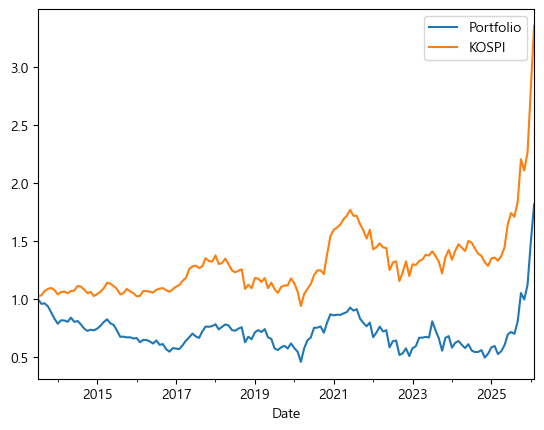

In [201]:
df_nav.plot()

---
**로그누적수익률 Plot**

<Axes: xlabel='Date'>

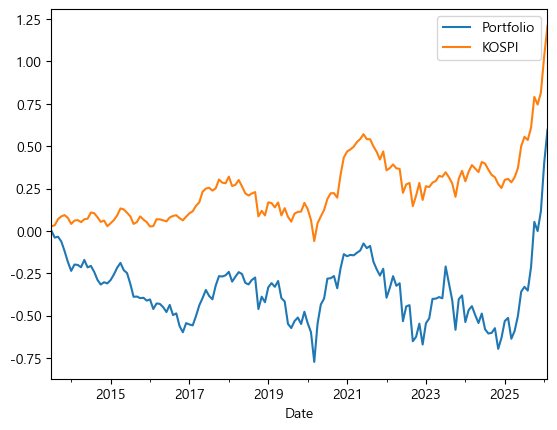

In [202]:
np.log1p(df_ret).cumsum().plot()

In [203]:
n_quantiles = 5

# 결과 저장용
portfolio_returns = pd.DataFrame(index=month_ends, columns=[f"Q{i}" for i in range(1, n_quantiles + 1)], dtype=float)
portfolio_trades  = pd.DataFrame(index=month_ends, columns=[f"Q{i}" for i in range(1, n_quantiles + 1)], dtype=float)

# 각 분위수별 상태 저장
nav_dict = {f"Q{i}": initial_NAV for i in range(1, n_quantiles + 1)}
prev_portfolios = {f"Q{i}": pd.Series(dtype=float) for i in range(1, n_quantiles + 1)}

# 초기 수익률
portfolio_returns.iloc[0] = 0.0

for t in range(len(month_ends) - 1):
    start_date = month_ends[t]
    end_date   = month_ends[t + 1]

    # 거래대금 하위 종목 제외
    trading_today = trading_value_60.loc[start_date].dropna()
    filtered = trading_today[trading_today > trading_today.quantile(trading_threshold)].index

    # factor 유효 종목
    factor_filtered = factor_df.loc[start_date, filtered].dropna()

    if factor_filtered.empty:
        continue

    # 분위수 라벨
    try:
        quantile_labels = pd.qcut(
            factor_filtered.rank(method="first"),
            q=n_quantiles,
            labels=False
        ) + 1
    except ValueError:
        continue

    # 유동성 비용 기준
    illiq_startdate = illiq.loc[start_date].dropna()
    threshold = illiq_startdate.quantile(illiq_threshold)
    illiquid_top20 = illiq_startdate[illiq_startdate >= threshold].index

    for q in range(1, n_quantiles + 1):
        q_name = f"Q{q}"
        NAV = nav_dict[q_name]
        prev_portfolio = prev_portfolios[q_name]

        basket = factor_filtered.index[quantile_labels == q]

        if len(basket) == 0:
            continue

        prev_weights = prev_portfolio / prev_portfolio.sum() if prev_portfolio.sum() != 0 else pd.Series(dtype=float)

        # 동일가중 / 시가총액가중
        if weight_method_temp == "Equal":
            target_weights = pd.Series(1.0 / len(basket), index=basket)
        else:
            cap = mkt_cap.loc[start_date, basket].dropna()
            if cap.empty or cap.sum() == 0:
                continue
            target_weights = cap / cap.sum()
            basket = target_weights.index

        # 거래비용 계산
        all_index = target_weights.index.union(prev_weights.index)
        target_w = target_weights.reindex(all_index, fill_value=0)
        prev_w   = prev_weights.reindex(all_index, fill_value=0)

        delta_w = target_w - prev_w
        trade_amounts = abs(delta_w) * NAV
        cost_rate = np.where(delta_w.index.isin(illiquid_top20), high_cost, low_cost)
        trade_cost = (trade_amounts * cost_rate).sum()

        NAV_after_cost = NAV - trade_cost
        current_portfolio_value = target_weights * NAV_after_cost

        # 다음 달 수익 반영
        ret_seg = monthly_rets_wins.loc[end_date, basket].dropna()
        common = current_portfolio_value.index.intersection(ret_seg.index)

        if len(common) == 0:
            continue

        next_portfolio_value = current_portfolio_value.loc[common] * (1 + ret_seg.loc[common])

        NAV_new = next_portfolio_value.sum()
        portfolio_ret = NAV_new / NAV - 1

        # 저장
        prev_portfolios[q_name] = next_portfolio_value
        nav_dict[q_name] = NAV_new

        portfolio_trades.loc[start_date, q_name] = trade_amounts.sum()
        portfolio_returns.loc[end_date, q_name] = portfolio_ret

In [204]:
portfolio_navs = (1 + portfolio_returns.fillna(0)).cumprod() * initial_NAV

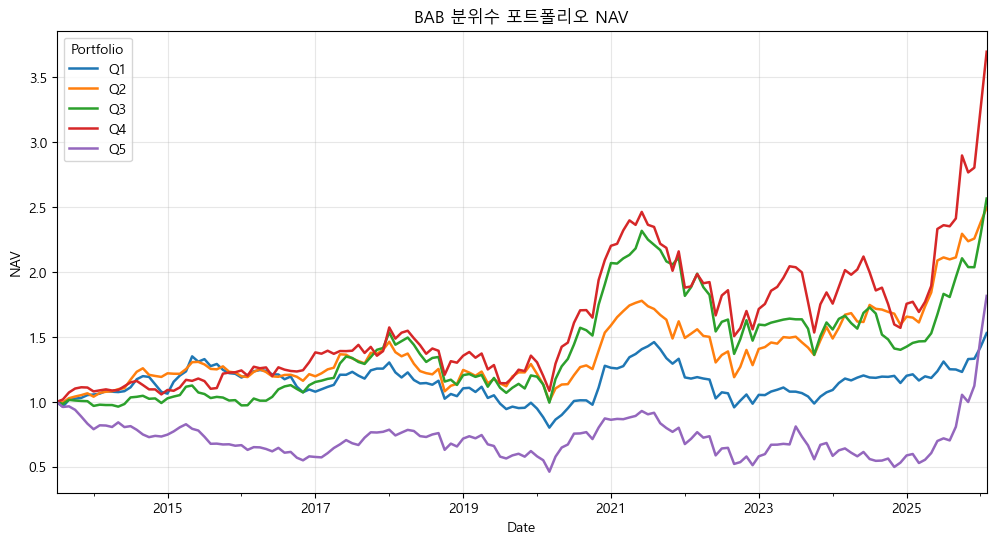

In [205]:
ax = portfolio_navs.plot(figsize=(12, 6), linewidth=1.8)
ax.set_title("BAB 분위수 포트폴리오 NAV")
ax.set_xlabel("Date")
ax.set_ylabel("NAV")
ax.grid(True, alpha=0.3)
plt.legend(title="Portfolio")
plt.show()

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


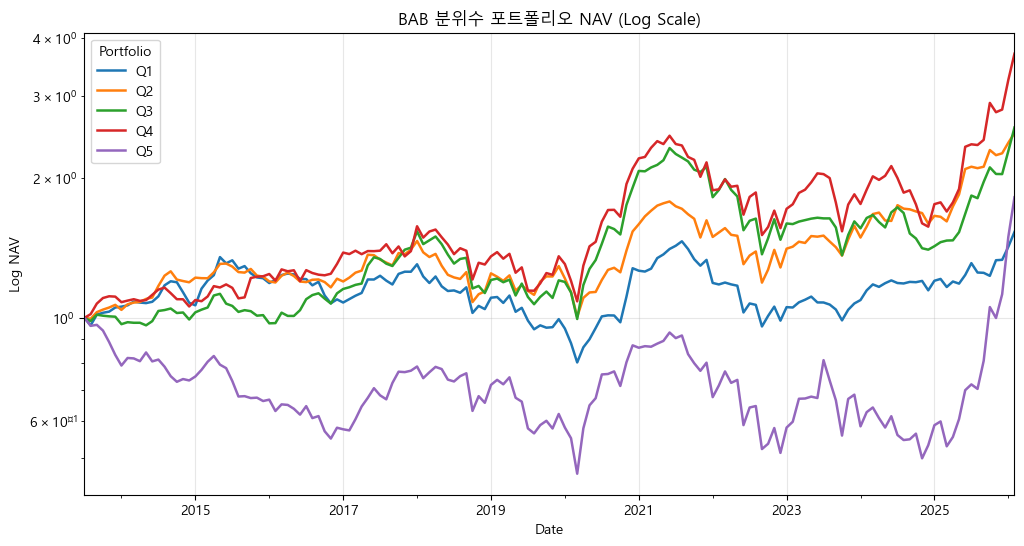

In [206]:
ax = portfolio_navs.plot(figsize=(12, 6), linewidth=1.8, logy=True)
ax.set_title("BAB 분위수 포트폴리오 NAV (Log Scale)")
ax.set_xlabel("Date")
ax.set_ylabel("Log NAV")
ax.grid(True, alpha=0.3)
plt.legend(title="Portfolio")
plt.show()